In [292]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import pickle

In [293]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\archive (6)\Sleep_Data_Sampled.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14996,14997,Female,59,Nurse,8.00,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14997,14998,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14998,14999,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [294]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy


In [295]:
df.shape

(15000, 13)

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                15000 non-null  int64  
 1   Gender                   15000 non-null  object 
 2   Age                      15000 non-null  int64  
 3   Occupation               15000 non-null  object 
 4   Sleep Duration           15000 non-null  float64
 5   Quality of Sleep         15000 non-null  int64  
 6   Physical Activity Level  15000 non-null  int64  
 7   Stress Level             15000 non-null  int64  
 8   BMI Category             15000 non-null  object 
 9   Blood Pressure           15000 non-null  object 
 10  Heart Rate               15000 non-null  int64  
 11  Daily Steps              15000 non-null  int64  
 12  Sleep Disorder           15000 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usage: 1.5+ MB


In [297]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.130667,6.997327,7.131267,59.925000,5.654800,70.857533,6795.080000
std,4330.271354,6.840091,0.615187,1.053111,16.814374,1.393568,3.614836,1329.706484
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,3750.750000,40.000000,6.500000,6.000000,45.000000,4.000000,68.000000,6000.000000
50%,7500.500000,44.000000,7.000000,7.000000,60.000000,6.000000,70.000000,6500.000000
75%,11250.250000,48.000000,7.450000,8.000000,75.000000,6.000000,72.000000,7600.000000
max,15000.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [298]:
df.isnull().sum()

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [299]:
df.duplicated().sum()

np.int64(0)

In [300]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

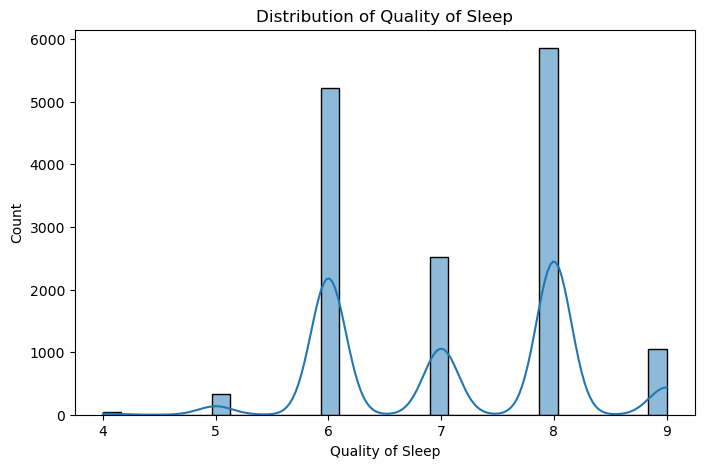

In [301]:
plt.figure(figsize=(8,5))

sns.histplot(df["Quality of Sleep"], kde=True)

plt.title("Distribution of Quality of Sleep")

plt.show()

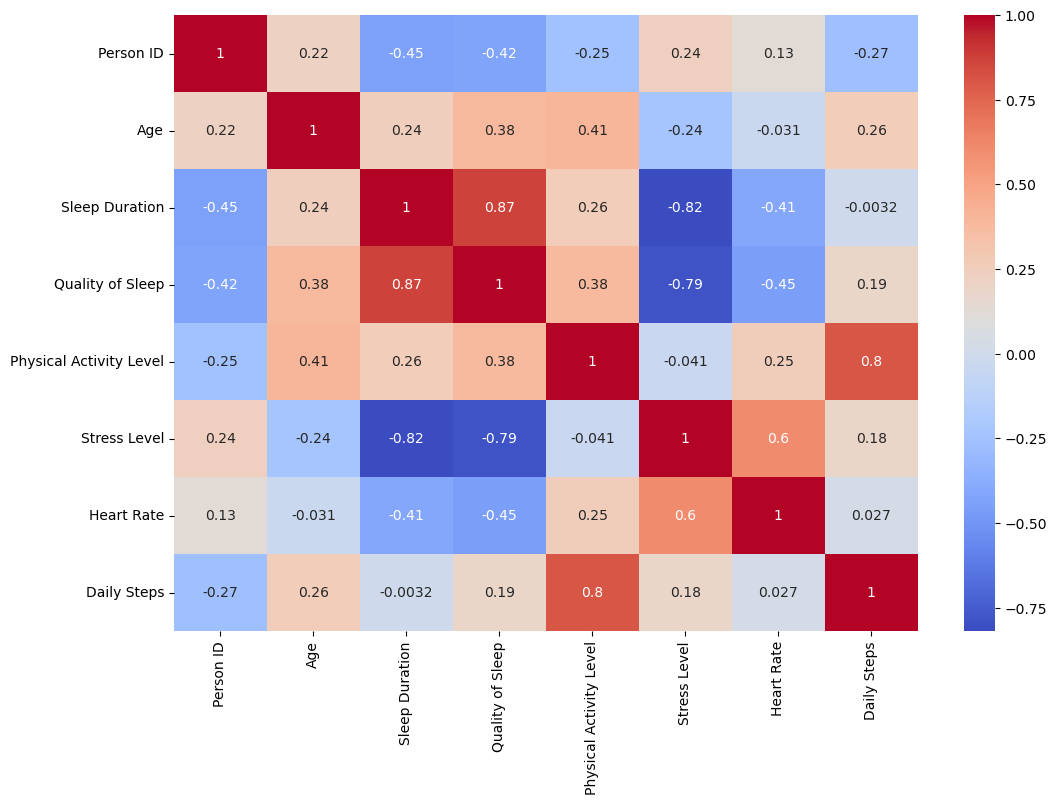

In [302]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")

plt.show()

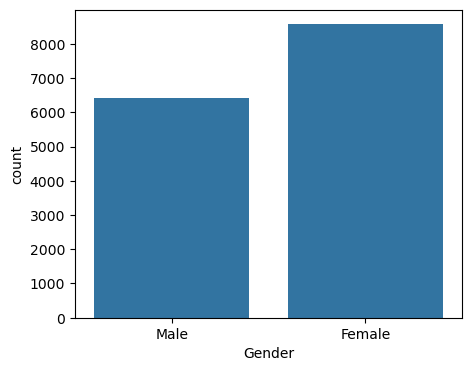

In [303]:
plt.figure(figsize=(5,4))

sns.countplot(x="Gender", data=df)

plt.show()

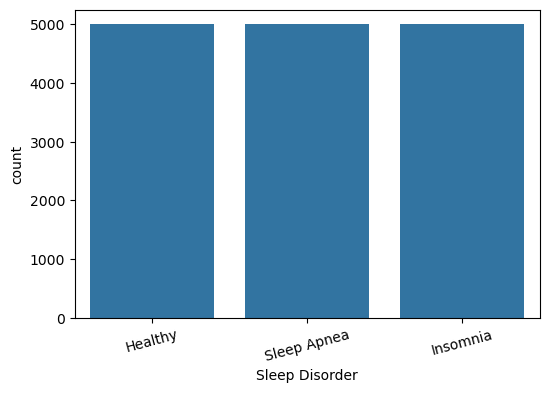

In [304]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sleep Disorder", data=df)

plt.xticks(rotation=15)

plt.show()

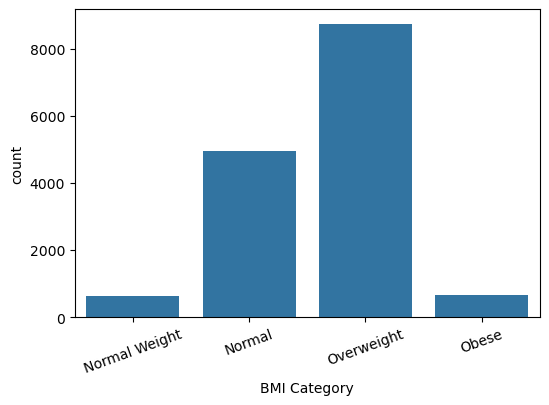

In [305]:
plt.figure(figsize=(6,4))

sns.countplot(x="BMI Category", data=df)

plt.xticks(rotation=20)

plt.show()

In [306]:
corr = df.select_dtypes(include=np.number).corr()

corr["Quality of Sleep"].sort_values(ascending=False)

Quality of Sleep           1.000000
Sleep Duration             0.871070
Age                        0.382186
Physical Activity Level    0.381601
Daily Steps                0.188875
Person ID                 -0.423943
Heart Rate                -0.451876
Stress Level              -0.785485
Name: Quality of Sleep, dtype: float64

In [307]:
# Data Preprocessing

In [308]:
df.drop("Person ID", axis=1, inplace=True)

In [309]:
# Split Blood Pressure into Systolic and Diastolic

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

# Convert to integer

df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

# Drop original Blood Pressure column

df.drop('Blood Pressure', axis=1, inplace=True)

In [310]:
df.dtypes

Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object

In [311]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
occupation_encoder = LabelEncoder()
bmi_encoder = LabelEncoder()
sleep_disorder_encoder = LabelEncoder()

df['Gender'] = gender_encoder.fit_transform(df['Gender'])

df['Occupation'] = occupation_encoder.fit_transform(df['Occupation'])

df['BMI Category'] = bmi_encoder.fit_transform(df['BMI Category'])

df['Sleep Disorder'] = sleep_disorder_encoder.fit_transform(df['Sleep Disorder'])

In [312]:
x = df.drop('Quality of Sleep', axis=1)

y = df['Quality of Sleep']

In [313]:
print(x.shape)
print(y.shape)

(15000, 12)
(15000,)


In [314]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [315]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [316]:
import pickle

artifacts = {
    "scaler": scaler,
    "gender_encoder": gender_encoder,
    "occupation_encoder": occupation_encoder,
    "bmi_encoder": bmi_encoder,
    "sleep_disorder_encoder": sleep_disorder_encoder,
    "feature_columns": X.columns.tolist()
}

with open("artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

In [317]:
import pickle

with open("artifacts.pkl", "rb") as file:
    artifacts = pickle.load(file)

print(artifacts.keys())

dict_keys(['scaler', 'gender_encoder', 'occupation_encoder', 'bmi_encoder', 'sleep_disorder_encoder', 'feature_columns'])


In [318]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [319]:
model = Sequential()

In [321]:
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='linear'))

C:\Users\DELL\Downloads\New folder\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [322]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                     │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [323]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [324]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [325]:
history = model.fit(x_train, y_train, validation_split=0.2, epochs=30, batch_size=64, callbacks=[early_stop], verbose=1)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 12.4141 - mae: 2.6422 - val_loss: 1.2133 - val_mae: 0.8550
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3303 - mae: 0.8994 - val_loss: 0.5470 - val_mae: 0.5521
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8292 - mae: 0.7116 - val_loss: 0.3052 - val_mae: 0.4122
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6125 - mae: 0.6112 - val_loss: 0.2223 - val_mae: 0.3529
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4960 - mae: 0.5499 - val_loss: 0.1719 - val_mae: 0.3061
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4215 - mae: 0.5059 - val_loss: 0.1734 - val_mae: 0.3243
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3494 - mae: 0.4591 - val_loss: 0.1630 - val_mae: 0.3174
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2921 - mae: 0.4190 - val_loss: 0.2088 - val_mae: 0.3744
Epoch 9/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - l

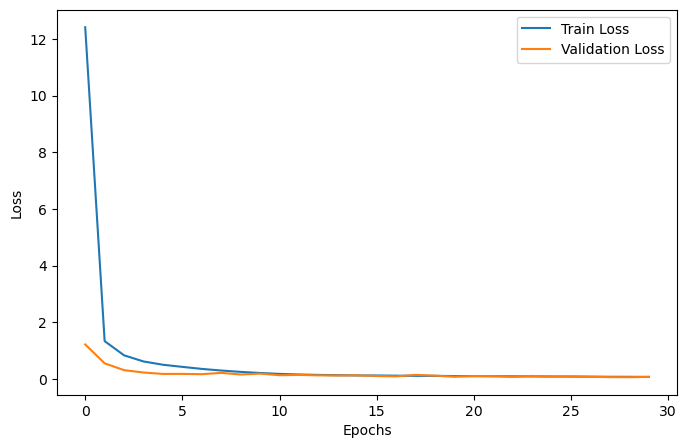

In [326]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

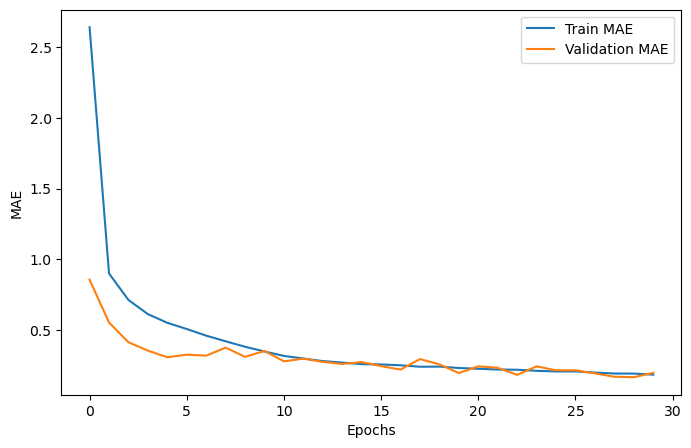

In [336]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

plt.show()

In [340]:
y_pred = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [341]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 0.16130918264389038
MSE : 0.053834524005651474
RMSE : 0.23202267993808595
R² Score : 0.9512820839881897


In [344]:
import pickle

artifacts = {
    "scaler": scaler,
    "gender_encoder": gender_encoder,
    "occupation_encoder": occupation_encoder,
    "bmi_encoder": bmi_encoder,
    "sleep_disorder_encoder": sleep_disorder_encoder,
    "feature_columns": x.columns.tolist()
}

with open("artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

In [345]:
with open("artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

print(artifacts["feature_columns"])

['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP']


In [330]:
model.save("sleep_quality_ann.keras")

print("Model saved successfully!")

Model saved successfully!


In [331]:
print(x.columns.tolist())

['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP']


In [332]:
print(x.columns.tolist())
print(len(x.columns))

['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP']
12


In [333]:
import pickle

with open("artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

print(artifacts.keys())
print(artifacts["feature_columns"])
print(len(artifacts["feature_columns"]))

dict_keys(['scaler', 'gender_encoder', 'occupation_encoder', 'bmi_encoder', 'sleep_disorder_encoder', 'feature_columns'])
['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Corruption_Perception', 'Unemployment_Rate', 'Education_Index', 'Population', 'Urbanization_Rate', 'Public_Trust', 'Mental_Health_Index', 'Income_Inequality', 'Public_Health_Expenditure', 'Climate_Index', 'Work_Life_Balance', 'Internet_Access', 'Crime_Rate', 'Political_Stability', 'Employment_Rate']
23
